# Estilometría de Ajedrez - CNN con Bloques
---

In [1]:
# SETUP
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import cv2
import random
import tensorflow as tf
from pathlib import Path
from keras import layers, losses, optimizers, metrics, Model
from keras.applications import resnet
from collections import defaultdict

print("TF version:", tf.__version__)

# Configurar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
        # Configuración adicional para RTX 5080
        tf.config.experimental.set_virtual_device_configuration(
            gpu,
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=12288)]  # 12GB límite
        )
    print(f"GPU configurada: {len(gpus)} dispositivo(s)")

# Parámetros
IMG_SHAPE = (96, 96)  # Reducido 4x (de 192)
BATCH_SIZE = 4  # Reducido drásticamente (de 32)
EPOCHS = 100  # Aumentado porque será más rápido
SEED = 314
NUM_BLOCKS = 5  # Reducido de 15 (inicio, medio, final)

# Reproducibilidad
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

2025-12-21 15:22:31.750401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-21 15:22:31.844471: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-21 15:22:31.876208: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-21 15:22:32.032181: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.17.0
GPU configurada: 1 dispositivo(s)


I0000 00:00:1766330556.396105     629 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766330556.770341     629 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766330556.770407     629 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.


## 1. Descubrir Eventos Disponibles

In [2]:
# pipeline
import importlib
sys.path.insert(0, str(Path('../src').resolve()))
import pipeline_stylometry_blocks
importlib.reload(pipeline_stylometry_blocks)
from pipeline_stylometry_blocks import discover_available_events

pgn_file = Path('../dataset/generated/lichess_db.pgn')

print("Escaneando PGN para descubrir eventos...\n")
events = discover_available_events(pgn_file, max_games=100000)

print("\n✓ Descubrimiento completado")
print(f"Total de eventos únicos: {len(events)}")

Escaneando PGN para descubrir eventos...


DESCUBRIMIENTO PARALELO DE EVENTOS (Optimizado RAM)
Archivo: ../dataset/generated/lichess_db.pgn
Workers: 8 (cores disponibles: 16)
RAM disponible: 11.5 GB
Límite: 100,000 partidas

Fase 1: Calculando límites de chunks...
  ✓ 1 chunks creados
  ✓ Tamaño total: 0.0 MB
  ✓ ~0.0 MB por chunk

Fase 2: Procesando chunks en paralelo...
(Usando streaming para minimizar uso de RAM)


Fase 3: Fusionando resultados...
  ✓ 0 partidas procesadas
  ✓ 0 eventos únicos encontrados


TOP 0 EVENTOS MÁS COMUNES

#    Evento                                     Partidas  Jugadores
----------------------------------------------------------------------

TOTAL: 0 eventos, 0 partidas


✓ Descubrimiento completado
Total de eventos únicos: 0


## 2. Seleccionar Evento y Ejecutar Pipeline

In [3]:
# Seleccionar evento
SELECTED_EVENT = "Rated Blitz game"

if SELECTED_EVENT in events:
    event_stats = events[SELECTED_EVENT]
    print(f"\nEvento seleccionado: {SELECTED_EVENT}")
    print(f"  Partidas disponibles: {event_stats['games']:,}")
    print(f"  Jugadores únicos: {event_stats['unique_players']:,}")

In [6]:
from pipeline_stylometry_blocks import ChessStylometryPipelineV002

pipeline = ChessStylometryPipelineV002(
    massive_pgn=pgn_file,
    output_base=Path('output'),
    event_type=SELECTED_EVENT,
    num_players=1000,              # Top 20 jugadores
    games_per_player=30,          # 30 partidas por jugador
    min_threshold=0.7,            # Mínimo 70% de partidas
    move_start=15,                # Movimiento inicial
    move_end=30,                  # Movimiento final (15 movimientos)
    num_blocks=15,                 # Dividir en n bloques
    compression_factor=1,         # Sin compresión (192x192)
    use_relative_time=True        # Tiempos relativos en heatmaps
)

stats = pipeline.run()


Pipeline de Estilometría - Bloques

Evento: Rated Blitz game
Bloques configurados: 15
  - block_01: movimientos 29-30
  - block_02: movimientos 31-32
  - block_03: movimientos 33-34
  - block_04: movimientos 35-36
  - block_05: movimientos 37-38
  - block_06: movimientos 39-40
  - block_07: movimientos 41-42
  - block_08: movimientos 43-44
  - block_09: movimientos 45-46
  - block_10: movimientos 47-48
  - block_11: movimientos 49-50
  - block_12: movimientos 51-52
  - block_13: movimientos 53-54
  - block_14: movimientos 55-56
  - block_15: movimientos 57-58
Output: output/events/Rated_Blitz_game

Jugadores ya extraídos (saltando fase 1)

Encontrados 1482 jugadores en: output/events/Rated_Blitz_game/player_pgns
Usando datos existentes...

  - A-gh-Chess1359
  - Aaden88
  - aaronkrause13
  - abab2525
  - AbAvS
  - ABCDosa
  - abdelhalim2024
  - ABDELMALIK111
  - abdelrhman62
  - Abdullah 850
  - Abdusattorov253030
  - Abeke 95
  - AbhinavMishra07
  - Abhi ami
  - abnormal adult 57
  -

## 3. Visualizar Resultados (Bloques)

In [4]:
# Visualizar imágenes de bloques de un jugador
event_safe = SELECTED_EVENT.replace(" ", "_").replace("/", "_")
event_dir = Path(f'./output/events/{event_safe}')

# Listar jugadores disponibles
board_dir = event_dir / 'board_images'
players = [d.name for d in board_dir.iterdir() if d.is_dir()]

print(f"Jugadores disponibles ({len(players)}):")
for i, player in enumerate(players[:10], 1):
    print(f"  {i}. {player.replace('_', ' ')}")

if len(players) > 10:
    print(f"  ... y {len(players)-10} más")

Jugadores disponibles (1482):
  1. A-gh-Chess1359
  2. Aaden88
  3. aaronkrause13
  4. abab2525
  5. AbAvS
  6. ABCDosa
  7. abdelhalim2024
  8. ABDELMALIK111
  9. abdelrhman62
  10. Abdullah 850
  ... y 1472 más



Visualizando partida 1 de A-gh-Chess1359


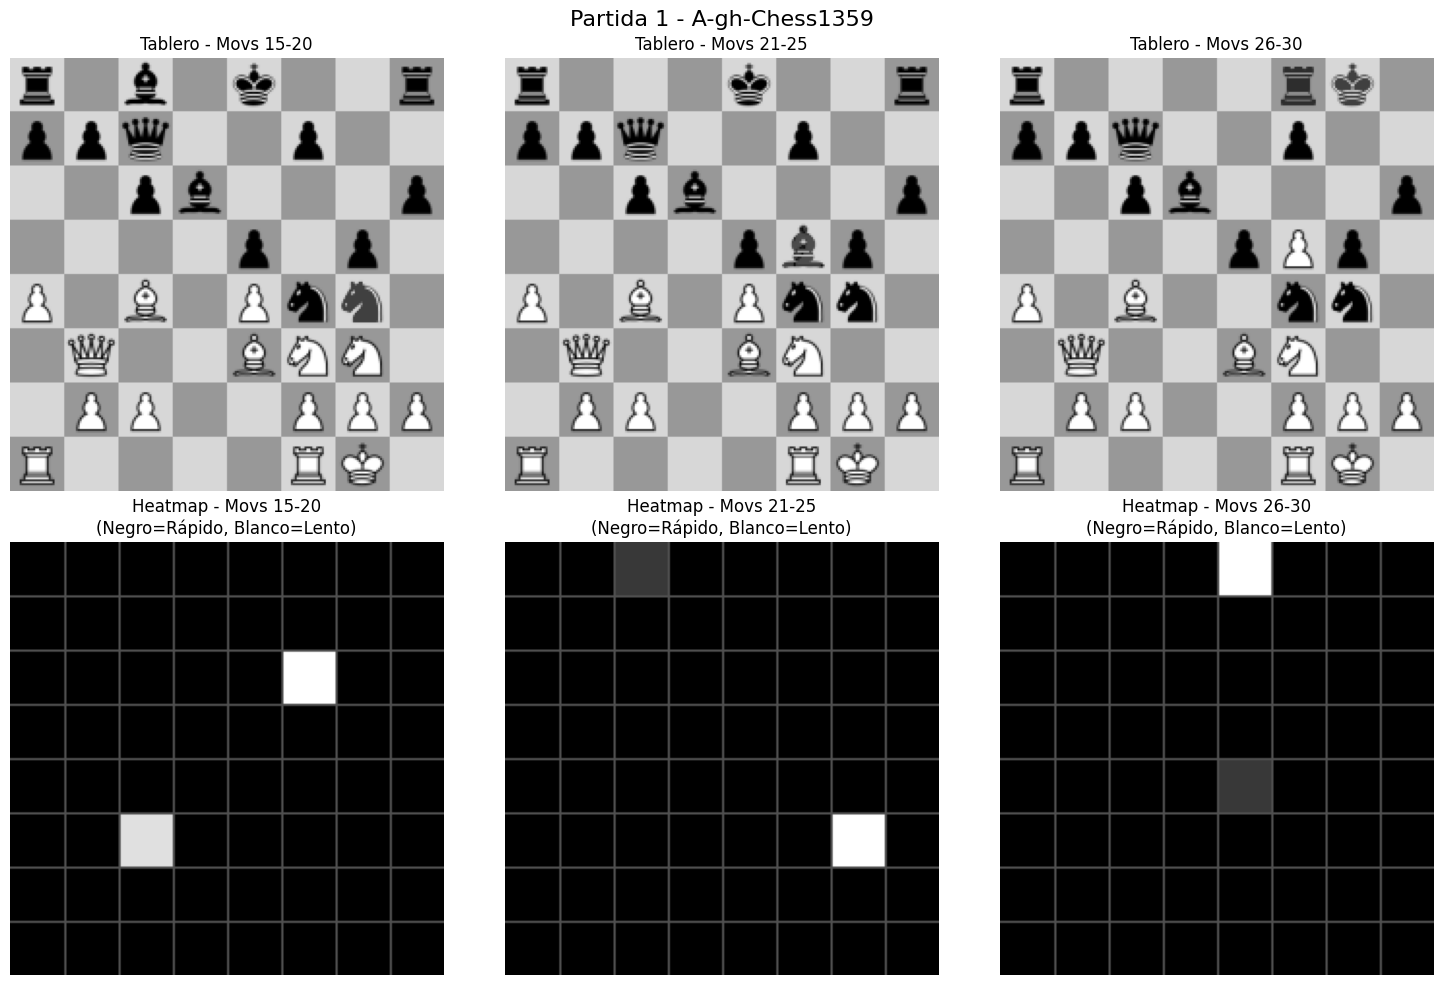


Interpretación de Heatmaps:
  - Negro/Oscuro: Decisiones rápidas (poco tiempo empleado)
  - Gris: Decisiones normales
  - Blanco/Claro: Decisiones lentas (mucho tiempo empleado)


In [5]:
# Mostrar bloques de una partida específica
player = players[0]  # Primer jugador
game_id = 1          # Primera partida

player_board_dir = board_dir / player
player_heat_dir = event_dir / 'heatmap_images' / player

print(f"\nVisualizando partida {game_id} de {player.replace('_', ' ')}")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Partida {game_id} - {player.replace('_', ' ')}", fontsize=16)

blocks = ['block_01', 'block_02', 'block_03']
block_labels = ['Movs 15-20', 'Movs 21-25', 'Movs 26-30']

for idx, (block, label) in enumerate(zip(blocks, block_labels)):
    # Tablero
    board_file = player_board_dir / f"game_{game_id:04d}_{block}.png"
    if board_file.exists():
        board_img = cv2.imread(str(board_file))
        board_img = cv2.cvtColor(board_img, cv2.COLOR_BGR2RGB)
        axes[0, idx].imshow(board_img)
        axes[0, idx].set_title(f"Tablero - {label}")
        axes[0, idx].axis('off')
    
    # Heatmap
    heat_file = player_heat_dir / f"game_{game_id:04d}_{block}.png"
    if heat_file.exists():
        heat_img = cv2.imread(str(heat_file))
        heat_img = cv2.cvtColor(heat_img, cv2.COLOR_BGR2RGB)
        axes[1, idx].imshow(heat_img, cmap='gray')
        axes[1, idx].set_title(f"Heatmap - {label}\n(Negro=Rápido, Blanco=Lento)")
        axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print("\nInterpretación de Heatmaps:")
print("  - Negro/Oscuro: Decisiones rápidas (poco tiempo empleado)")
print("  - Gris: Decisiones normales")
print("  - Blanco/Claro: Decisiones lentas (mucho tiempo empleado)")

## A mejorar

Resulta que no se ven muchas de las jugadas, del mov 15-20 [Partida (https://lichess.org/997Q8NVt#30)] por ejemplo no se ve que realmente en la casilla de dama blanca (g4) había un alfil antes, no se renderiza

## 4. Preparar Dataset para Entrenamiento

Con los bloques, cada partida genera 3 pares de imágenes (tablero + heatmap).

In [6]:
import sys
if 'multi_channel_generator' in sys.modules:
    del sys.modules['multi_channel_generator']
from multi_channel_generator import create_train_val_generators

In [7]:
from multi_channel_generator import create_train_val_generators

print("Creando generadores de datos (MEMORY EFFICIENT)...")
train_gen, val_gen = create_train_val_generators(
    event_dir=event_dir,
    players=players,
    num_blocks=NUM_BLOCKS,
    img_shape=IMG_SHAPE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    seed=SEED
)

player_to_id = train_gen.get_player_to_id()

print(f"\nGeneradores creados:")
print(f"  Jugadores: {len(players)}")
print(f"  Train batches: {len(train_gen)}")
print(f"  Val batches: {len(val_gen)}")
print(f"  Bloques por muestra: {NUM_BLOCKS}")
print(f"  Canales totales: {NUM_BLOCKS * 2}")
print(f"  Memoria usada: MÍNIMA (solo 1 batch en RAM)")

Creando generadores de datos (MEMORY EFFICIENT)...
Generador inicializado: 22019 partidas, 1482 jugadores
Generador inicializado: 22019 partidas, 1482 jugadores
Generador inicializado: 22019 partidas, 1482 jugadores
Train: 17616 muestras, 4404 batches
Val: 4403 muestras, 1101 batches

Generadores creados:
  Jugadores: 1482
  Train batches: 4404
  Val batches: 1101
  Bloques por muestra: 5
  Canales totales: 10
  Memoria usada: MÍNIMA (solo 1 batch en RAM)


## 5. Construir Modelo Siamés con Dual Channel

Arquitectura:
- **Canal 1**: Tablero (RGB, 192x192x3)
- **Canal 2**: Heatmap Grayscale (192x192x1)
- Procesamiento separado con CNNs
- Fusión de features
- Clasificación de jugadores

In [8]:
#%pip uninstall tensorflow -y
#%pip install tf-nightly-gpu

In [9]:
from multi_channel_model import build_multi_channel_model
# Construir modelo con N canales (N bloques * 2: tableros + heatmaps)
model = build_multi_channel_model(
    num_players=len(players),
    num_blocks=NUM_BLOCKS,
    img_shape=IMG_SHAPE)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
print(f"\nModelo construido con {NUM_BLOCKS} bloques ({NUM_BLOCKS * 2} canales):")
model.summary()

I0000 00:00:1766332453.051407     629 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766332453.051564     629 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766332453.051599     629 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1766332453.298251     629 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-12-21 15:54:13.298298: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2112] Could not identify NUMA node of platform GPU id 0, defaulting to 0.  Your kernel may not have been built with NUMA support.


Modelo construido con 5 bloques (10 canales):


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board_input_block_… │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ board_input_block_… │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ board_input_block_… │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ board_input_block_… │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ board_input_block_… │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ heat_input_block_01 │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ heat_input_block_02 │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ heat_input_block_03 │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ heat_input_block_04 │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ heat_input_block_05 │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │        896 │ board_input_bloc… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 96, 96,    │        896 │ board_input_bloc… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 96, 96,    │        896 │ board_input_bloc… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 96, 96,    │        896 │ board_input_bloc… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 96, 96,    │        896 │ board_input_bloc… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 96,    │        320 │ heat_input_block… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 96, 96,    │        320 │ heat_input_block

 Total params: 1,940,874 (7.40 MB)

 Trainable params: 1,940,874 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 🔍 PRUEBA DE VELOCIDAD DEL GENERADOR
import time

print("\n" + "="*70)
print("🚀 PRUEBA DE VELOCIDAD - Cargando 10 batches...")
print("="*70)

times = []
for i in range(10):
    start = time.time()
    batch = train_gen[i]
    elapsed = time.time() - start
    times.append(elapsed)
    print(f"Batch {i+1:2d}: {elapsed:.3f}s")

avg_time = np.mean(times)
print(f"\n📊 Promedio: {avg_time:.3f}s/batch")
print(f"📊 Tiempo estimado por época: {avg_time * len(train_gen) / 60:.1f} minutos")
print(f"📊 Tiempo total ({EPOCHS} épocas): {avg_time * len(train_gen) * EPOCHS / 3600:.1f} horas")

if avg_time > 2:
    print("\n⚠️  ADVERTENCIA: Muy lento (>2s/batch)")
    print("   Considera reducir más NUM_BLOCKS o IMG_SHAPE")
elif avg_time < 0.5:
    print("\n✅ Excelente velocidad (<0.5s/batch)")
else:
    print("\n✅ Velocidad aceptable")

print("="*70)



🚀 PRUEBA DE VELOCIDAD - Cargando 10 batches...
Batch  1: 0.320s
Batch  2: 0.333s
Batch  3: 0.335s
Batch  4: 0.310s
Batch  5: 0.326s
Batch  6: 0.315s
Batch  7: 0.306s
Batch  8: 0.311s
Batch  9: 0.314s
Batch 10: 0.302s

📊 Promedio: 0.317s/batch
📊 Tiempo estimado por época: 23.3 minutos
📊 Tiempo total (100 épocas): 38.8 horas

✅ Excelente velocidad (<0.5s/batch)


## 6. Entrenar Modelo

In [11]:
# Split train/val ya está hecho por el generador
# Saltar esta celda
print("Split ya realizado por el generador (80/20)")
print(f"  Train: {train_gen.get_sample_count()} muestras")
print(f"  Val: {val_gen.get_sample_count()} muestras")

Split ya realizado por el generador (80/20)
  Train: 17616 muestras
  Val: 4403 muestras


In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("\n Inicio de entrenamiento...")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n Entrenamiento completado")


Entrenando modelo con generadores...
Epoch 1/100
4404/4404 ━━━━━━━━━━━━━━━━━━━━ 2103s 477ms/step - accuracy: 0.0018 - loss: 6.8710 - val_accuracy: 0.0014 - val_loss: 6.9337 - learning_rate: 0.0010
Epoch 2/100
4404/4404 ━━━━━━━━━━━━━━━━━━━━ 2017s 458ms/step - accuracy: 0.0024 - loss: 6.8569 - val_accuracy: 0.0014 - val_loss: 6.9470 - learning_rate: 0.0010
Epoch 3/100
4404/4404 ━━━━━━━━━━━━━━━━━━━━ 1786s 405ms/step - accuracy: 0.0024 - loss: 6.8650 - val_accuracy: 0.0014 - val_loss: 6.9595 - learning_rate: 0.0010
Epoch 4/100
4404/4404 ━━━━━━━━━━━━━━━━━━━━ 2731s 620ms/step - accuracy: 0.0020 - loss: 6.8528 - val_accuracy: 0.0014 - val_loss: 6.9671 - learning_rate: 0.0010
Epoch 5/100
4404/4404 ━━━━━━━━━━━━━━━━━━━━ 2751s 624ms/step - accuracy: 0.0021 - loss: 6.8614 - val_accuracy: 0.0014 - val_loss: 6.9821 - learning_rate: 0.0010
Epoch 6/100
3971/4404 ━━━━━━━━━━━━━━━━━━━━ 2:59 414ms/step - accuracy: 0.0020 - loss: 6.8521 

## 7. Evaluar y Visualizar Resultados

In [ ]:
# Plot training history
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Accuracy
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)
# Loss
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()
# Final metrics
val_loss, val_acc = model.evaluate(val_inputs, y_val, verbose=0)
print(f"\nResultados finales:")
print(f"  Validation Accuracy: {val_acc*100:.2f}%")
print(f"  Validation Loss: {val_loss:.4f}")

In [ ]:
# Guardar modelo
model_dir = Path('../models/v002')
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / f'v0022_blocks_{SELECTED_EVENT.replace(" ", "_")}.keras'
model.save(model_path)

print(f"✓ Modelo guardado: {model_path}")

In [ ]:
## Los resultados no tienen buena pinta